# Data 1. NASA FLDAS (FEWS NET Land Data Assimilation System)
- 식량 안보 모니터링을 위해 NASA에서 제공하는 데이터
- 관측 데이터(CHIRPS 포함)를 기반으로 지면 모델(Noah 3.6.1) 시뮬레이션된 값
- 업데이트 주기 : monthly (매월 중순)
- 해상도 : 0.1 deg (약 11 km)

## 추출된 변수
- 아래 항목들을 Z-score (월별 평균을 빼고 표준편차로 나눈 값)로 변환(평년 기준은 1991~2020년)
- 추가로 직전 3개월, 6개월 관측 값도 함께 계산(state variable은 평균, flux variable은 누적합)
- State Variables
  - 평균 기온(Tair_f_tavg)
  - 지표면 복사 온도(RadT_tavg)
  - 토양 수분량(표층; ~10cm)(SoilMoi00_10cm_tavg)
  - 토양 수분량(뿌리층; 10~40cm)(SoilMoi10_40cm_tavg)
  - 토양 수분량(0~40cm)(SoilMoi00_40cm_tavg) : 위 2개 합한 값
- Flux Variables
  - 강수 플럭스(Rainf_f_tavg)
  - 증발산량(Evap_tavg)
  - 유출량(Surface)(Qs_tavg)
  - 유출량(Subsurface)(Qsb_tavg)
  - 총 유출량(Total_Runoff_tavg) : 위 2개 합한 값
  - 수분 균형(Water_Balance_tavg) : Rainf_f_tavg - Evap_tavg (SPEI 대체)

In [ ]:
import ee

# ⚠️ 중요: 아래에 사용 중인 Google Cloud Project ID를 입력해야 합니다.
# GEE Code Editor (https://code.earthengine.google.com/) 우측 상단 등에서 확인 가능합니다.
project_id = 'wfp-project-486106'

# GEE 인증 및 초기화
try:
    ee.Initialize(project=project_id)
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project=project_id)

In [ ]:
# ==========================================
# 🚀 사용자 설정 (Double Buffer Logic)
# ==========================================
ROI = ee.Geometry.Rectangle([25, -15, 52, 22]) # 동아프리카

# [1] 평년(Reference) 기간 설정 + 버퍼
REF_START = '1991-01-01'
REF_END = '2020-12-31'
REF_BUFFER_START = '1990-06-01' # 1991년 1월의 6개월 Rolling을 위한 버퍼

# [2] 분석(Target) 기간 설정 + 버퍼
TARGET_START = '2007-01-01'
TARGET_END = '2025-12-31'
BUFFER_START = '2006-06-01'     # 2007년 1월의 6개월 Rolling을 위한 버퍼

EXPORT_DESC = 'EastAfrica_FLDAS_Final_Corrected_2007_2025'
WINDOW_SIZES = [1, 3, 6]
# ==========================================

In [ ]:
# 1. FLDAS 데이터 로드
raw_fldas = ee.ImageCollection("NASA/FLDAS/NOAH01/C/GL/M/V001").select(
    ['Tair_f_tavg', 'RadT_tavg', 'SoilMoi00_10cm_tavg', 'SoilMoi10_40cm_tavg',
     'Rainf_f_tavg', 'Evap_tavg', 'Qs_tavg', 'Qsb_tavg']
)

# 2. 파생 변수 생성
def add_derived_bands(img):
    sm_00_40 = img.select('SoilMoi00_10cm_tavg').add(img.select('SoilMoi10_40cm_tavg')) \
                  .rename('SoilMoi00_40cm_tavg')
    total_q = img.select('Qs_tavg').add(img.select('Qsb_tavg')) \
                 .rename('Total_Runoff_tavg')
    wb = img.select('Rainf_f_tavg').subtract(img.select('Evap_tavg')) \
            .rename('Water_Balance_tavg')
    return img.addBands([sm_00_40, total_q, wb])

fldas_augmented = raw_fldas.map(add_derived_bands)

# ---------------------------------------------------------
# 3. 변수 그룹 정의
# ---------------------------------------------------------
STATE_VARS = ['Tair_f_tavg', 'RadT_tavg', 'SoilMoi00_10cm_tavg',
              'SoilMoi10_40cm_tavg', 'SoilMoi00_40cm_tavg']
FLUX_VARS = ['Rainf_f_tavg', 'Evap_tavg', 'Qs_tavg', 'Qsb_tavg',
             'Total_Runoff_tavg', 'Water_Balance_tavg']

In [ ]:
# ---------------------------------------------------------
# 4. Rolling & Anomaly 계산 로직 (에러 수정됨)
# ---------------------------------------------------------
def get_rolling_anomaly(full_collection, months):

    # (A) 공통 Rolling 함수 (기존과 동일)
    def apply_rolling(img, collection_scope):
        current_date = img.date()
        start_date = current_date.advance(-(months - 1), 'month')
        rolling_subset = collection_scope.filterDate(start_date, current_date.advance(1, 'day'))

        img_state = rolling_subset.select(STATE_VARS).mean()
        img_flux = rolling_subset.select(FLUX_VARS).sum()

        suffix = f'_{months}mon'
        new_state = [n.replace('_tavg', suffix) for n in STATE_VARS]
        new_flux = [n.replace('_tavg', suffix) for n in FLUX_VARS]

        return img_state.rename(new_state) \
                        .addBands(img_flux.rename(new_flux)) \
                        .copyProperties(img, ['system:time_start'])

    # (B) 평년값(Climatology) 계산 단계 [수정됨]
    ref_calc_col = full_collection.filterDate(REF_BUFFER_START, REF_END)
    # 자기 자신 참조를 위해 map 내부 로직 주의
    ref_rolling_raw = ref_calc_col.map(lambda img: apply_rolling(img, ref_calc_col))
    ref_valid_col = ref_rolling_raw.filterDate(REF_START, REF_END)

    # [수정 핵심 1] Python Dict 대신 ee.Image 리스트 사용
    # Mean 밴드와 Std 밴드를 하나의 이미지로 합쳐서 저장합니다.
    monthly_stats_images = []

    # 밴드 이름을 미리 파악하기 위한 샘플 이미지 (이름 규칙 생성용)
    sample_img = ref_valid_col.first()
    band_names = sample_img.bandNames()

    for m in range(1, 13):
        ref_m = ref_valid_col.filter(ee.Filter.calendarRange(m, m, 'month'))
        mean_img = ref_m.mean()
        std_img = ref_m.reduce(ee.Reducer.stdDev())

        # Std 이미지의 밴드 이름에 '_std' 접미사를 붙여서 이름 충돌 방지
        std_renamed = std_img.rename(band_names.map(lambda n: ee.String(n).cat('_std')))

        # Mean 이미지에 Std 이미지를 붙여서 하나의 'Stats Image'로 만듦
        stats_img = mean_img.addBands(std_renamed).set('month', m)

        # 이 이미지를 리스트에 추가 (이제 GEE가 이해하는 객체임)
        monthly_stats_images.append(stats_img)

    # 리스트를 GEE 객체로 변환
    ee_monthly_stats = ee.List(monthly_stats_images)

    # (C) 분석(Target) 기간 Anomaly 계산 단계
    target_calc_col = full_collection.filterDate(BUFFER_START, TARGET_END)
    target_rolling_raw = target_calc_col.map(lambda img: apply_rolling(img, target_calc_col))

    # [수정 핵심 2] 저장된 통계 이미지를 불러와서 분리 및 계산
    def compute_z(img):
        m = img.date().get('month')
        # 리스트에서 해당 월의 통계 이미지(Mean+Std)를 가져옴
        stats_img = ee.Image(ee_monthly_stats.get(m.subtract(1)))

        # 원본 이름 그대로인 밴드들은 Mean
        mean = stats_img.select(band_names)

        # '_std'가 붙은 밴드들은 Std (가져온 후 다시 원본 이름으로 되돌려야 연산 가능)
        std = stats_img.select(stats_img.bandNames().filter(ee.Filter.stringEndsWith('item', '_std'))) \
                       .rename(band_names) # 이름을 맞춰줘야 divide 연산이 됨

        z_score = img.subtract(mean).divide(std)

        old_names = z_score.bandNames()
        new_names = old_names.map(lambda n: ee.String(n).cat('_Z'))
        return z_score.rename(new_names).copyProperties(img, ['system:time_start'])

    target_anomaly = target_rolling_raw.map(compute_z)

    # (D) Final Crop
    final_output = target_anomaly.filterDate(TARGET_START, TARGET_END)

    return final_output

In [ ]:
# ---------------------------------------------------------
# 5. 실행 및 병합 (수정됨)
# ---------------------------------------------------------
final_collection = None
print("GEE 연산 그래프 생성 중 (Double Buffer Logic Applied)...")

for w in WINDOW_SIZES: # [1, 3, 6]
    print(f"  - {w}개월 Rolling 처리 중...")
    res_col = get_rolling_anomaly(fldas_augmented, w)

    if final_collection is None:
        final_collection = res_col
    else:
        # Inner Join으로 밴드 병합
        filter_time = ee.Filter.equals(leftField='system:time_start', rightField='system:time_start')
        join = ee.Join.saveFirst(matchKey='match')

        combined = join.apply(final_collection, res_col, filter_time)

        # [수정 핵심] img를 ee.Image(img)로 감싸서 이미지임을 명시해야 addBands가 작동함
        def merge_bands(img):
            primary = ee.Image(img)  # Feature -> Image 변환
            secondary = ee.Image(img.get('match'))
            return primary.addBands(secondary)

        final_collection = ee.ImageCollection(combined.map(merge_bands))

GEE 연산 그래프 생성 중 (Double Buffer Logic Applied)...
  - 1개월 Rolling 처리 중...
  - 3개월 Rolling 처리 중...
  - 6개월 Rolling 처리 중...


In [ ]:
# ---------------------------------------------------------
# [수정됨] 6. 연도별 분할 내보내기 (Export Loop)
# ---------------------------------------------------------
# 단일 파일 제한(5000 밴드)을 피하기 위해 1년 단위로 끊어서 저장합니다.

years = list(range(2007, 2026)) # 2007 ~ 2025

print(f"총 {len(years)}개의 연도별 파일을 생성합니다...")

for y in years:
    # 1. 해당 연도만 필터링
    start_date = f'{y}-01-01'
    end_date = f'{y}-12-31'

    # filterDate는 끝 날짜가 포함되지 않으므로 하루 더해줌
    year_col = final_collection.filterDate(start_date, ee.Date(end_date).advance(1, 'day'))

    # 데이터가 있는지 확인 (혹시 모르니)
    count = year_col.size().getInfo()
    if count == 0:
        print(f"  ⚠️ {y}년 데이터 없음. 건너뜀.")
        continue

    # 2. 파일명 설정 (예: EastAfrica_FLDAS_2007.tif)
    desc_str = f"{EXPORT_DESC}_{y}"

    # 3. 내보내기 작업 생성
    task = ee.batch.Export.image.toDrive(
        image=year_col.toBands(), # 1년치(12개월)만 펼치므로 밴드 수 약 360개 -> 안전함!
        description=desc_str,
        folder='GEE_FLDAS_Exports', # 같은 폴더에 저장됨
        region=ROI,
        scale=11132, # 0.1도
        crs='EPSG:4326',
        fileFormat='GeoTIFF',
        maxPixels=1e13
    )

    task.start()
    print(f"  Running: {y}년 데이터 Export 요청 완료")

print("\n🚀 모든 연도 작업 요청이 완료되었습니다!")
print("구글 드라이브 'GEE_FLDAS_Exports' 폴더에 파일이 하나씩 생길 겁니다.")

총 19개의 연도별 파일을 생성합니다...
  Running: 2007년 데이터 Export 요청 완료
  Running: 2008년 데이터 Export 요청 완료
  Running: 2009년 데이터 Export 요청 완료
  Running: 2010년 데이터 Export 요청 완료
  Running: 2011년 데이터 Export 요청 완료
  Running: 2012년 데이터 Export 요청 완료
  Running: 2013년 데이터 Export 요청 완료
  Running: 2014년 데이터 Export 요청 완료
  Running: 2015년 데이터 Export 요청 완료
  Running: 2016년 데이터 Export 요청 완료
  Running: 2017년 데이터 Export 요청 완료
  Running: 2018년 데이터 Export 요청 완료
  Running: 2019년 데이터 Export 요청 완료
  Running: 2020년 데이터 Export 요청 완료
  Running: 2021년 데이터 Export 요청 완료
  Running: 2022년 데이터 Export 요청 완료
  Running: 2023년 데이터 Export 요청 완료
  Running: 2024년 데이터 Export 요청 완료
  Running: 2025년 데이터 Export 요청 완료

🚀 모든 연도 작업 요청이 완료되었습니다!
구글 드라이브 'GEE_FLDAS_Exports' 폴더에 파일이 하나씩 생길 겁니다.


In [ ]:
# 최근 19개의 작업 상태 확인
tasks = ee.batch.Task.list()

print("=== GEE 작업 목록 (최근 19개) ===")
for task in tasks[:19]:
    # 작업 설명, 상태, ID 출력
    print(f"[{task.config['description']}] : {task.state}")

    # 만약 에러가 났다면 에러 메시지 출력
    if task.state == 'FAILED':
        print(f"  ❌ 에러 원인: {task.status()['error_message']}")

=== GEE 작업 목록 (최근 19개) ===
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2025] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2024] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2023] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2022] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2021] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2020] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2019] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2018] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2017] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2016] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2015] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2014] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2013] : READY
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2012] : RUNNING
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2011] : RUNNING
[EastAfrica_FLDAS_Final_Corrected_2007_2025_2010] : RUNNING
[EastAfrica_FLDAS_Final_Corrected_2007_

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.0 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 사용자 설정: 파일 경로 확인
# ==========================================
# 구글 드라이브 내 GEE_FLDAS_Exports 폴더 경로
base_path = '/content/drive/MyDrive/GEE_FLDAS_Exports'
filename = 'EastAfrica_FLDAS_Final_Corrected_2007_2025_2007.tif' # 확인하고 싶은 파일명
file_path = os.path.join(base_path, filename)

# 파일이 있는지 확인
if not os.path.exists(file_path):
    print(f"❌ 파일이 아직 없습니다: {file_path}")
    print("드라이브 동기화가 덜 되었거나, 작업이 아직 진행 중입니다.")
else:
    print(f"✅ 파일 발견! 검증을 시작합니다: {filename}")

✅ 파일 발견! 검증을 시작합니다: EastAfrica_FLDAS_Final_Corrected_2007_2025_2007.tif


In [ ]:
# 1. 데이터 로드 (rioxarray 사용)
# GeoTIFF는 밴드 이름이 메타데이터에 숨어있을 수 있어 engine='rasterio'가 유리함
ds = xr.open_dataset(file_path, engine='rasterio')

print("\n--- [1] 데이터 차원 확인 ---")
print(ds)


--- [1] 데이터 차원 확인 ---
<xarray.Dataset> Size: 327MB
Dimensions:      (band: 396, x: 271, y: 381)
Coordinates:
  * band         (band) int64 3kB 1 2 3 4 5 6 7 ... 390 391 392 393 394 395 396
  * x            (x) float64 2kB 24.95 25.05 25.15 25.25 ... 51.75 51.85 51.95
  * y            (y) float64 3kB 22.55 22.45 22.35 ... -15.25 -15.35 -15.45
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float64 327MB ...


In [ ]:
# 2. 밴드 이름(변수명) 확인
# GEE toBands()를 쓰면 밴드 이름이 "20070101_Tair_f_1mon_Z" 처럼 변환됨
# long_name 속성이나 band_data 등을 확인
try:
    band_names = ds['band_data'].attrs.get('long_name', ds.band_data.values)
    print(f"\n--- [2] 밴드 개수: {len(ds.band_data)}개 ---")
    print("밴드명 예시:", np.array(band_names[:int(len(ds.band_data)/12)]))
except:
    print("밴드 이름을 바로 불러오지 못했습니다. (xarray 기본 인덱스 사용 중)")


--- [2] 밴드 개수: 396개 ---
밴드명 예시: ['200701_Tair_f_1mon_Z' '200701_RadT_1mon_Z'
 '200701_SoilMoi00_10cm_1mon_Z' '200701_SoilMoi10_40cm_1mon_Z'
 '200701_SoilMoi00_40cm_1mon_Z' '200701_Rainf_f_1mon_Z'
 '200701_Evap_1mon_Z' '200701_Qs_1mon_Z' '200701_Qsb_1mon_Z'
 '200701_Total_Runoff_1mon_Z' '200701_Water_Balance_1mon_Z'
 '200701_Tair_f_3mon_Z' '200701_RadT_3mon_Z'
 '200701_SoilMoi00_10cm_3mon_Z' '200701_SoilMoi10_40cm_3mon_Z'
 '200701_SoilMoi00_40cm_3mon_Z' '200701_Rainf_f_3mon_Z'
 '200701_Evap_3mon_Z' '200701_Qs_3mon_Z' '200701_Qsb_3mon_Z'
 '200701_Total_Runoff_3mon_Z' '200701_Water_Balance_3mon_Z'
 '200701_Tair_f_6mon_Z' '200701_RadT_6mon_Z'
 '200701_SoilMoi00_10cm_6mon_Z' '200701_SoilMoi10_40cm_6mon_Z'
 '200701_SoilMoi00_40cm_6mon_Z' '200701_Rainf_f_6mon_Z'
 '200701_Evap_6mon_Z' '200701_Qs_6mon_Z' '200701_Qsb_6mon_Z'
 '200701_Total_Runoff_6mon_Z' '200701_Water_Balance_6mon_Z']


In [ ]:
# 3. 특정 변수(예: SPEI 대체재인 Water Balance 3mon) 추출 및 시각화
# 보통 밴드 순서는 날짜별로 정렬되어 있음.
# 여기서는 임의로 첫 번째 시간대(2007년 1월)의 특정 밴드를 그려봅니다.

# 데이터는 (band, y, x) 형태임
# 2007년 1월 데이터 중 하나를 선택해본다. (값이 모두 NaN이 아닌지 확인)
sample_data = ds.band_data[0] # 첫 번째 밴드 (보통 1월달 첫 변수)

print("\n--- [3] 통계값 검증 (Z-score 여부) ---")
# Z-score라면 평균은 0 근처, 범위는 -5 ~ +5 사이여야 정상
valid_values = sample_data.values[~np.isnan(sample_data.values)]

if len(valid_values) == 0:
    print("⚠️ 경고: 유효한 데이터가 하나도 없습니다! (모두 NaN/Masked)")
else:
    print(f"최소값: {valid_values.min():.4f}")
    print(f"최대값: {valid_values.max():.4f}")
    print(f"평균값: {valid_values.mean():.4f}")

    if valid_values.min() < -10 or valid_values.max() > 10:
        print("⚠️ 주의: Z-score 범위(-3~3)를 크게 벗어난 값들이 있습니다.")
    else:
        print("✅ 정상: 값들이 표준정규분포(Z-score) 범위 내에 있습니다.")


--- [3] 통계값 검증 (Z-score 여부) ---
최소값: -2.1133
최대값: 3.6443
평균값: -0.5415
✅ 정상: 값들이 표준정규분포(Z-score) 범위 내에 있습니다.


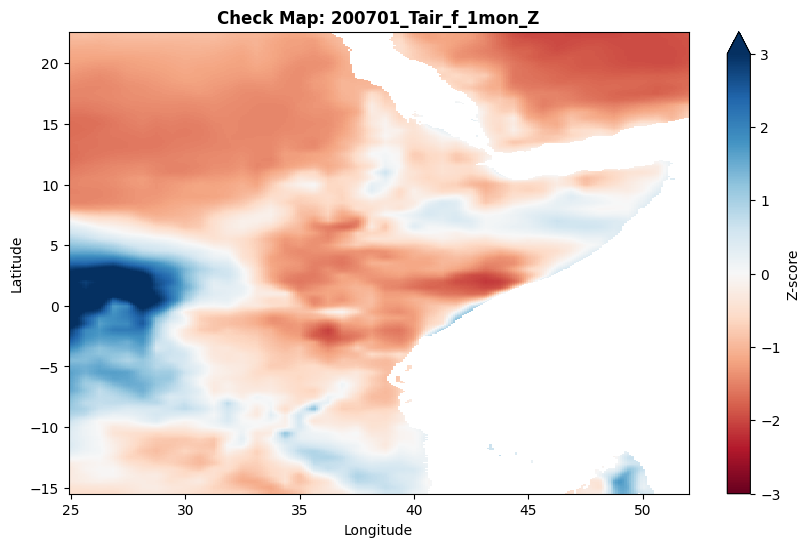

In [ ]:
# 4. 지도 그리기 (수정됨)
plt.figure(figsize=(10, 6))

# [핵심] xarray가 자동으로 가져오는 긴 이름을 강제로 짧게 수정
# 이렇게 하면 범례(Colorbar) 옆에 'Z-score'라고 깔끔하게 나옵니다.
sample_data.attrs['long_name'] = 'Anomaly (Z-score)'
sample_data.attrs['units'] = 'Std Dev'

# 플롯 그리기
# add_labels=False를 하면 X축, Y축, 제목이 자동으로 안 붙습니다 (수동 설정 가능)
# 여기서는 범례는 필요하니까 놔두고, 제목만 우리가 직접 답니다.
sample_data.plot(
    cmap='RdBu',
    vmin=-3,
    vmax=3,
    cbar_kwargs={'label': 'Z-score'} # 범례 라벨 강제 지정
)

# 밴드 이름에서 날짜와 변수명 추출해보기 (파일명이 보통 '20070101_변수명' 형식임)
# GeoTIFF의 경우 밴드 이름이 long_name 속성의 n번째 값에 숨어있을 수 있습니다.
try:
    # rasterio로 열었을 때 long_name은 튜플로 들어오는 경우가 많음
    full_names = ds.band_data.attrs.get('long_name', [])
    current_band_name = full_names[0] if len(full_names) > 0 else "Band 1"
except:
    current_band_name = "Band 1"

# 제목 깔끔하게 달기
plt.title(f"Check Map: {current_band_name}", fontsize=12, fontweight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()